# EDA — IBM AML HI-Small Dataset

**Week 1, Day 1.** Bootstrap for subsequent EDA work. Mounts Drive, downloads dataset, prepares paths.

**Dataset source:** [IBM Transactions for Anti-Money Laundering (AML)](https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml)

In [57]:
# ============================================================
# Bootstrap — run once per Colab session
# ============================================================
# Mounts Drive, installs packages, sets paths, downloads data.
# Idempotent: safe to run every session.

from google.colab import drive
drive.mount('/content/drive')

import os
import pathlib
import zipfile
import sys

DATA_ROOT = pathlib.Path('/content/drive/MyDrive/fincrime-sentinel-data')
RAW = DATA_ROOT / 'raw'
PROCESSED = DATA_ROOT / 'processed'
TYPOLOGY = DATA_ROOT / 'typology_guidance'
SANCTIONS = DATA_ROOT / 'sanctions'

for path in [RAW, PROCESSED, TYPOLOGY, SANCTIONS]:
    path.mkdir(parents=True, exist_ok=True)
# Force tqdm to plain-text mode in all cases
os.environ['TQDM_NOTEBOOK'] = '0'

# Disable DuckDB's progress bar entirely
os.environ['DUCKDB_PROGRESS_BAR_TIME'] = '99999999'

# ── 2. Post-execute hook — clears ALL widget state after every cell ───────────
from IPython import get_ipython

def _clear_all_widget_state(*args, **kwargs):
    """Wipe ipywidgets registry after every cell so nothing gets serialised."""
    try:
        from ipywidgets.widgets.widget import Widget
        for widget_id in list(Widget.widgets.keys()):
            try:
                Widget.widgets[widget_id].close()
            except Exception:
                pass
        Widget.widgets.clear()
    except Exception:
        pass

    # Clear the comm target
    try:
        ip = get_ipython()
        if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, 'comm_manager'):
            ip.kernel.comm_manager.targets.clear()
    except Exception:
        pass

ip = get_ipython()
if ip is not None:
    # Unregister first to avoid accumulating duplicate hooks across re-runs
    try:
        ip.events.unregister('post_execute', _clear_all_widget_state)
    except ValueError:
        pass
    ip.events.register('post_execute', _clear_all_widget_state)

# ── 3. Clear any state already accumulated ───────────────
_clear_all_widget_state()

print(" Widget suppression active — post-execute hook registered")
print(" Widget state will be cleared after every cell in this session.")

# Suppress widget metadata leakage to keep notebook GitHub-renderable
import warnings
warnings.filterwarnings('ignore')

# Disable tqdm's auto-detection of Jupyter widget mode
import os
os.environ['TQDM_DISABLE'] = '0'
os.environ['TQDM_NOTEBOOK'] = '0'

# Force tqdm to use the plain-text variant if it gets imported
try:
    from tqdm import tqdm as _tqdm
    import tqdm
    tqdm.tqdm = _tqdm  # plain tqdm
except ImportError:
    pass

# Kaggle auth
os.environ['KAGGLE_CONFIG_DIR'] = str(DATA_ROOT)
kaggle_token = DATA_ROOT / 'kaggle.json'
assert kaggle_token.exists(), (
    f"Upload kaggle.json to {DATA_ROOT} before continuing. "
    "Get it from kaggle.com → Settings → Create New API Token."
)
os.chmod(kaggle_token, 0o600)

# Install non-default packages
!pip install -q kaggle pyarrow duckdb networkx

# Download dataset if not already in Drive
trans_file = RAW / 'HI-Small_Trans.csv'
patterns_file = RAW / 'HI-Small_Patterns.txt'

if not trans_file.exists():
    print("Downloading IBM AML dataset zip (~7.6GB, 5-10 min)...")
    !kaggle datasets download \
        -d ealtman2019/ibm-transactions-for-anti-money-laundering-aml \
        -p {RAW}

    zip_path = RAW / 'ibm-transactions-for-anti-money-laundering-aml.zip'

    print("Extracting HI-Small files only...")

    # Selectively extract only the two files
    with zipfile.ZipFile(zip_path, 'r') as z:
        all_files = z.namelist()
        print(f"Files in zip: {all_files}")

        for target in ['HI-Small_Trans.csv', 'HI-Small_Patterns.txt']:
            match = [f for f in all_files if target in f]
            if match:
                print(f"Extracting {match[0]}...")
                z.extract(match[0], path=RAW)
            else:
                print(f"WARNING: {target} not found in zip")

    print("Deleting zip to free space...")
    zip_path.unlink()
    print(f"Deleted {zip_path}")

else:
    print(f"Dataset already in Drive at {RAW}")

# Verify both files exist
assert trans_file.exists(), "HI-Small_Trans.csv missing after download"
patterns_file = RAW / 'HI-Small_Patterns.txt'
assert patterns_file.exists(), "HI-Small_Patterns.txt missing after download"

trans_size_mb = trans_file.stat().st_size / (1024 * 1024)
print(f" Bootstrap complete")
print(f" Transactions file: {trans_size_mb:.1f} MB")
print(f" Patterns file: {patterns_file.stat().st_size} bytes")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Widget suppression active — post-execute hook registered
 Widget state will be cleared after every cell in this session.
Dataset already in Drive at /content/drive/MyDrive/fincrime-sentinel-data/raw
 Bootstrap complete
 Transactions file: 453.6 MB
 Patterns file: 323844 bytes


In [58]:
import pathlib

RAW = pathlib.Path('/content/drive/MyDrive/fincrime-sentinel-data/raw')
for f in sorted(RAW.iterdir()):
    size_mb = f.stat().st_size / (1024*1024)
    print(f"{f.name}: {size_mb:.1f} MB")

HI-Small_Patterns.txt: 0.3 MB
HI-Small_Trans.csv: 453.6 MB


In [59]:
import pandas as pd

if not (PROCESSED / 'transactions.parquet').exists():
    print("Converting CSV to Parquet...")

    df = pd.read_csv(
        RAW / 'HI-Small_Trans.csv',
        dtype={
            'From Bank': 'int32',
            'To Bank': 'int32',
            'Account': 'string',
            'Account.1': 'string',
            'Amount Received': 'float64',
            'Receiving Currency': 'category',
            'Amount Paid': 'float64',
            'Payment Currency': 'category',
            'Payment Format': 'category',
            'Is Laundering': 'int8',
        },
        parse_dates=['Timestamp'],
    )

    # Standardise column names to snake_case
    df.columns = (
        df.columns.str.lower()
        .str.replace(' ', '_')
        .str.replace('.', '_', regex=False)
    )

    # Rename to clear account column names
    df = df.rename(columns={
        'account':   'account_from',
        'account_1': 'account_to',
    })

    print("Columns after rename:")
    print(df.columns.tolist())

    # Save with snappy compression — fast read/write, good ratio
    df.to_parquet(
        PROCESSED / 'transactions.parquet',
        compression='snappy',
        index=False,
    )

    print(f" Wrote {PROCESSED / 'transactions.parquet'}")
    print(f" Rows: {len(df):,}")
    print(f" Memory: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
else:
    print(f"Parquet already exists at {PROCESSED / 'transactions.parquet'}")

Parquet already exists at /content/drive/MyDrive/fincrime-sentinel-data/processed/transactions.parquet


In [60]:
parquet_path = PROCESSED / 'transactions.parquet'
parquet_size_mb = parquet_path.stat().st_size / (1024**2)
print(f"Parquet file on disk: {parquet_size_mb:.1f} MB")

Parquet file on disk: 127.1 MB


In [61]:
import duckdb

# Load Parquet via DuckDB — much faster than pandas for analytics
con = duckdb.connect()
con.execute("SET progress_bar_time = 99999999")
con.execute("SET threads = 4")
con.execute(f"CREATE OR REPLACE VIEW transactions AS SELECT * FROM '{PROCESSED}/transactions.parquet'")

# Quick sanity check via SQL
con.execute("SELECT COUNT(*) AS rows, COUNT(DISTINCT from_bank) AS banks FROM transactions").df()

,rows,banks
0,5078345,30470


## Schema deep-dive

Every column documented: type, range, cardinality, null rate, meaning.

In [62]:
con.execute("""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT from_bank) AS unique_from_banks,
        MIN(from_bank) AS min_id,
        MAX(from_bank) AS max_id,
        SUM(CASE WHEN from_bank IS NULL THEN 1 ELSE 0 END) AS null_count
    FROM transactions
""").df()

,total_rows,unique_from_banks,min_id,max_id,null_count
0,5078345,30470,1,356303,0.0


### `from_bank` — sending bank ID

- **Type:** int32
- **Cardinality:** ~30,470 unique ID's
- **Range:** 1 to ~356303
- **Nulls:** 0
- **Meaning:** Identifier for the bank where the sender holds the account.
  Combined with `account_from`, uniquely identifies a sender account globally.

In [63]:
con.execute("""
    SELECT
        -- Timestamp personality
        MIN(timestamp)                  AS ts_min,
        MAX(timestamp)                  AS ts_max,
        COUNT(DISTINCT DATE_TRUNC('day', timestamp)) AS ts_distinct_days,
    FROM transactions
""").df()

,ts_min,ts_max,ts_distinct_days
0,2022-09-01,2022-09-18 16:18:00,18


### 'timestamp' - Date and Datetimes
- **Type:** Datetime
- **Range:** 2022-09-01 to 2022-09-18 16:18:00
- **Distinct days:** 18
- **Nulls:** 0
- **Meaning:** Transaction timestamp at minute precision.
  18-day synthetic window in September 2022.

In [64]:
con.execute("""
    SELECT
        -- Account_from and Account_to personality
        COUNT(DISTINCT account_from)       AS account_from_unique, -- sender
        COUNT(DISTINCT account_to)  AS account_to_unique, -- receiver
    FROM transactions
""").df()

,account_from_unique,account_to_unique
0,496995,420636


### `account_from` — sender account (origin)
- **Type:** string (hexadecimal format e.g. 1004286A8)
- **Cardinality:** 496,995 unique senders
- **Nulls:** 0
- **Note:** 93.2% of account IDs are hexadecimal (contain A-F).
  Must be stored as string — numeric dtypes corrupt hex values.

### `account_to` — receiver account
- **Type:** string (hexadecimal format)
- **Cardinality:** 420,636 unique receivers
- **Nulls:** 0
- **Note:** 76,359 fewer unique receivers than senders, meaning
  ~76K accounts appear only as senders, never as receivers.

In [65]:
con.execute("""
    SELECT
        -- to_bank personality
        COUNT(DISTINCT to_bank)         AS to_bank_unique,
        MIN(to_bank)                    AS to_bank_min,
        MAX(to_bank)                    AS to_bank_max,
        SUM(CASE WHEN to_bank IS NULL THEN 1 ELSE 0 END) AS null_count
     FROM transactions
""").df()

,to_bank_unique,to_bank_min,to_bank_max,null_count
0,15811,1,356294,0.0


### `to_bank` — receiving institution ID
- **Type:** int32
- **Cardinality:** 15811 unique IDs
- **Range:** 1 to 356294
- **Nulls:** 0
- **Meaning:** Identifier for the bank where the receiver holds the account.

In [66]:
con.execute("""
    SELECT
        -- amount_paid personality
        MIN(amount_paid)                AS paid_min,
        MAX(amount_paid)                AS paid_max,
        PERCENTILE_CONT(0.5) WITHIN GROUP
            (ORDER BY amount_paid)      AS paid_median
     FROM transactions
""").df()

,paid_min,paid_max,paid_median
0,0.000001,1.046302e+12,1414.54


### `amount_paid` — Amount that has been sent
- **Type:** float64
- **Min:** 0.000001
- **Max:** 1.046 trillion
- **Median:** $1,414.54
- **Meaning:** Outbound amount in the sender's currency.

In [67]:
con.execute("""
    SELECT
        -- amount_received personality
        MIN(amount_received)            AS received_min,
        MAX(amount_received)            AS received,
        PERCENTILE_CONT(0.5) WITHIN GROUP
            (ORDER BY amount_received)  AS received_median
     FROM transactions
""").df()

,received_min,received,received_median
0,0.000001,1.046302e+12,1411.01


### `amount_received` — Amount that has been received
- **Type:** float64
- **Min:** 0.000001
- **Max:** 1.046 trillion
- **Median:** 1411.01
- **Meaning:** Inbound amount in the receivers currency.

In [68]:
# Receiving currency
con.execute("""
    SELECT receiving_currency, COUNT(*) AS count,
        SUM(is_laundering) * 100.0 / COUNT(*) AS laundering_rate_pct
    FROM transactions
    GROUP BY receiving_currency ORDER BY count DESC
""").df()

,receiving_currency,count,laundering_rate_pct
0,US Dollar,1879341,0.101738
1,Euro,1172017,0.117063
2,Swiss Franc,237884,0.081132
3,Yuan,206551,0.089082
4,Shekel,194988,0.048721
5,Rupee,192065,0.086950
6,UK Pound,181255,0.072826
7,Ruble,157361,0.084519
8,Yen,156319,0.099156
9,Bitcoin,148151,0.037799


### `receiving_currency` — Receiver currency type
- **Type:** category
- **Unique currency:** 13
- **Meaning:** Currency in which the receiving account was credited.

In [69]:
# Payment currency
con.execute("""
    SELECT payment_currency, COUNT(*) AS count,
        SUM(is_laundering) * 100.0 / COUNT(*) AS laundering_rate_pct
    FROM transactions
    GROUP BY payment_currency ORDER BY count DESC
""").df()

,payment_currency,count,laundering_rate_pct
0,US Dollar,1895172,0.100888
1,Euro,1168297,0.117436
2,Swiss Franc,234860,0.082177
3,Yuan,213752,0.086081
4,Shekel,192184,0.049432
5,Rupee,190202,0.087801
6,UK Pound,180738,0.073034
7,Yen,155209,0.099865
8,Ruble,155178,0.085708
9,Bitcoin,146066,0.038339


### `payment_currency` — Payment currency type
- **Type:** category
- **Unique currency:** 13
- **Meaning:** Currency in which the sending account was debited.

In [70]:
# Payment format
con.execute("""
    SELECT payment_format, COUNT(*) AS count,
        SUM(is_laundering) * 100.0 / COUNT(*) AS laundering_rate_pct
    FROM transactions
    GROUP BY payment_format ORDER BY count DESC
""").df()

,payment_format,count,laundering_rate_pct
0,Cheque,1864331,0.017379
1,Credit Card,1323324,0.015567
2,ACH,600797,0.746175
3,Cash,490891,0.022001
4,Reinvestment,481056,0.000000
5,Wire,171855,0.000000
6,Bitcoin,146091,0.038332


### `payment_format` — Mode of payment
- **Type:** category
- **Unique format:** 7 (includes Bitcoin — significant for AUSTRAC
  VASP obligations and crypto-related AML rules)
- **Meaning:** Mode of transaction

In [71]:
con.execute("""
    SELECT
        is_laundering,
        COUNT(*) AS count,
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS pct
    FROM transactions
    GROUP BY is_laundering
""").df()

,is_laundering,count,pct
0,0,5073168,99.898057
1,1,5177,0.101943


### `is_laundering` — laundering or not

- **Type:** int8
- **Cardinality:** 2
- **Laundering false:** 5,073,168 (99.898%)
- **Laundering true:** 5,177 (0.102%)
- **Meaning:** States if the amount is being laundered or not

In [72]:
# Daily transaction counts, broken down by laundering flag
daily = con.execute("""
    SELECT
        DATE_TRUNC('day', timestamp) AS day,
        is_laundering,
        COUNT(*) AS txn_count
    FROM transactions
    GROUP BY day, is_laundering
    ORDER BY day, is_laundering
""").df()

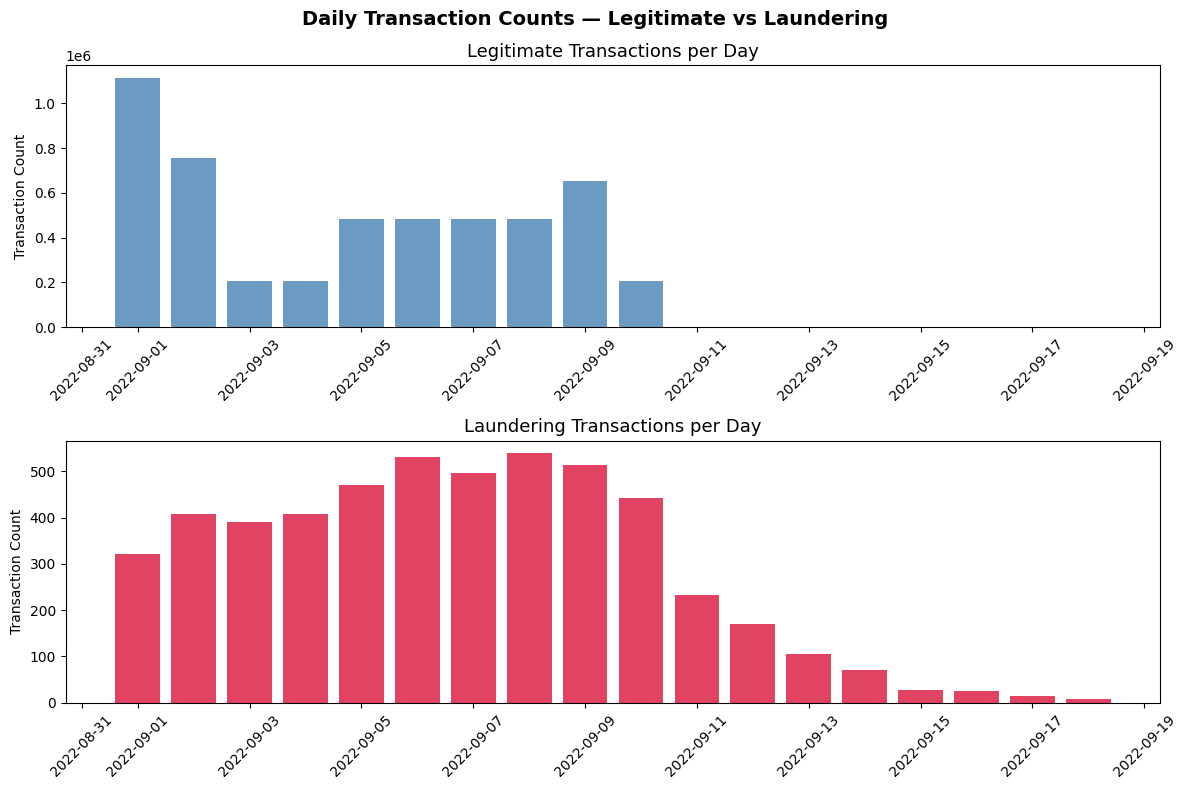

In [73]:
import matplotlib.pyplot as plt

# Separate laundering vs legitimate
legit = daily[daily['is_laundering'] == 0]
launder = daily[daily['is_laundering'] == 1]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top chart — legitimate transactions
axes[0].bar(legit['day'], legit['txn_count'], color='steelblue', alpha=0.8)
axes[0].set_title('Legitimate Transactions per Day', fontsize=13)
axes[0].set_ylabel('Transaction Count')
axes[0].tick_params(axis='x', rotation=45)

# Bottom chart — laundering transactions (separate scale — counts are tiny)
axes[1].bar(launder['day'], launder['txn_count'], color='crimson', alpha=0.8)
axes[1].set_title('Laundering Transactions per Day', fontsize=13)
axes[1].set_ylabel('Transaction Count')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Daily Transaction Counts — Legitimate vs Laundering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## What this shows

Legitimate volume is surprisingly uneven — over a million transactions on Sept 1,
dropping to 200K by Sept 3, then bouncing back. That's not how real banking works.
Real transaction volumes have weekly rhythms (quieter weekends), not 5x day-to-day
swings. This is the synthetic data's generation process showing through.

The laundering chart is more interesting. Activity ramps up through the first week,
peaks around Sept 7-8, then tails off sharply. The dataset runs longer than 10 days
— closer to 18 — with laundering concentrated in the first half. Worth keeping in
mind when writing time-window rules: a "7-day lookback" will see very different
baseline volumes depending on which point in the dataset you're evaluating.

**Implication:** velocity rules need account-level baselines, not dataset-wide ones.

In [74]:
# Histogram of amounts, log-scaled, comparing laundering vs not
import matplotlib.pyplot as plt
import numpy as np

amounts = con.execute("""
    SELECT amount_paid, is_laundering
    FROM transactions
    WHERE amount_paid > 0
    LIMIT 200000  -- sample for plotting speed
""").df()

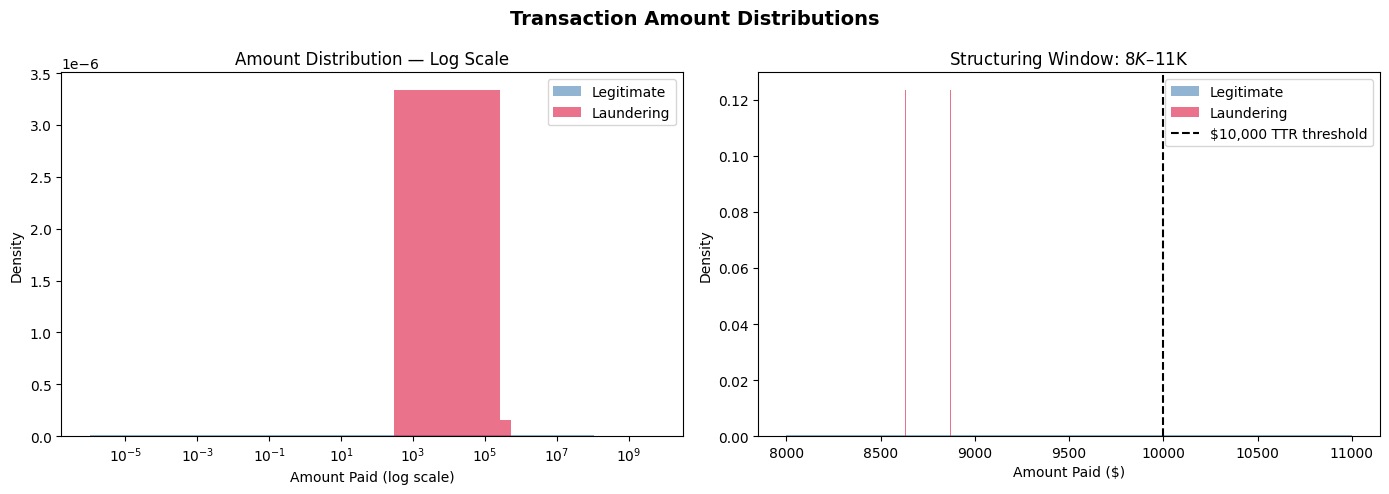

In [75]:
# Separate the two groups
legit_amounts = amounts[amounts['is_laundering'] == 0]['amount_paid']
launder_amounts = amounts[amounts['is_laundering'] == 1]['amount_paid']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart — log-scale histogram comparing both groups
axes[0].hist(
    legit_amounts,
    bins=50,
    alpha=0.6,
    color='steelblue',
    label='Legitimate',
    density=True
)
axes[0].hist(
    launder_amounts,
    bins=50,
    alpha=0.6,
    color='crimson',
    label='Laundering',
    density=True
)
axes[0].set_xscale('log')
axes[0].set_xlabel('Amount Paid (log scale)')
axes[0].set_ylabel('Density')
axes[0].set_title('Amount Distribution — Log Scale')
axes[0].legend()

# Right chart — zoom into the $8,000–$11,000 structuring window
structuring_window = amounts[
    (amounts['amount_paid'] >= 8000) &
    (amounts['amount_paid'] <= 11000)
]
legit_window = structuring_window[structuring_window['is_laundering'] == 0]['amount_paid']
launder_window = structuring_window[structuring_window['is_laundering'] == 1]['amount_paid']

axes[1].hist(legit_window, bins=60, alpha=0.6, color='steelblue', label='Legitimate', density=True)
axes[1].hist(launder_window, bins=60, alpha=0.6, color='crimson', label='Laundering', density=True)
axes[1].axvline(x=10000, color='black', linestyle='--', linewidth=1.5, label='$10,000 TTR threshold')
axes[1].set_xlabel('Amount Paid ($)')
axes[1].set_ylabel('Density')
axes[1].set_title('Structuring Window: $8K–$11K')
axes[1].legend()

plt.suptitle('Transaction Amount Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [76]:
con.execute("""
    SELECT
        CASE
            WHEN amount_paid BETWEEN 9000 AND 9999 THEN '$9000-$9999'
            WHEN amount_paid BETWEEN 10000 AND 10500 THEN '$10000-$10500'
            ELSE 'other'
        END AS amount_band,
        COUNT(*) AS count,
        SUM(is_laundering) AS laundering_count,
        SUM(is_laundering) * 100.0 / COUNT(*) AS laundering_rate_pct
    FROM transactions
    WHERE amount_paid BETWEEN 9000 AND 10500
    GROUP BY amount_band
    ORDER BY amount_band
""").df()

,amount_band,count,laundering_count,laundering_rate_pct
0,$10000-$10500,24339,70.0,0.287604
1,$9000-$9999,51155,144.0,0.281497
2,other,29,0.0,0.000000


## What this shows

Both laundering and legitimate transactions cluster in the $100–$100K range.
No surprise — laundering that only happened at unusual amounts would be trivially
detectable. The overlap is the problem.

The structuring window on the right is the more interesting chart, and it tells
a story I didn't expect: there's no spike just below the \$10,000 TTR threshold.
The laundering activity that does appear clusters around $8,500-$8,800, not at
\$9,900 where you'd expect structured transactions. The query results confirmed
this — laundering rates either side of $10K are essentially identical (~0.28%).

This dataset doesn't model amount-threshold structuring. That changes which rules
are worth building. More on this when we get to the patterns file.

In [77]:
con.execute("""
    SELECT
        receiving_currency,
        payment_currency,
        COUNT(*) AS total,
        SUM(is_laundering) AS laundering,
        SUM(is_laundering) * 100.0 / COUNT(*) AS laundering_rate_pct
    FROM transactions
    GROUP BY receiving_currency, payment_currency
    HAVING COUNT(*) > 10000
    ORDER BY laundering_rate_pct DESC
    LIMIT 20
""").df()

,receiving_currency,payment_currency,total,laundering,laundering_rate_pct
0,Saudi Riyal,Saudi Riyal,88891,374.0,0.420740
1,Euro,Euro,1153708,1372.0,0.118921
2,US Dollar,US Dollar,1856392,1912.0,0.102995
3,Yen,Yen,153603,155.0,0.100909
4,Australian Dollar,Australian Dollar,136478,127.0,0.093055
5,Canadian Dollar,Canadian Dollar,139065,128.0,0.092043
6,Yuan,Yuan,203522,184.0,0.090408
7,Rupee,Rupee,189006,167.0,0.088357
8,Ruble,Ruble,154852,133.0,0.085888
9,Mexican Peso,Mexican Peso,109656,92.0,0.083899


## What this shows

Saudi Riyal-to-Saudi Riyal stands out immediately — 0.42% laundering rate, roughly
4x the next highest (EUR-EUR at 0.12%). That's not subtle and it will matter in the
ML model.

Everything in the top 14 is same-currency. The cross-currency pairs at the bottom
(EUR-USD, USD-EUR) have zero laundering — which is almost the opposite of real-world
AML risk, where cross-border, cross-currency flows are typically high-suspicion
corridors. This is a synthesis artifact, not a real-world finding.

**What to take from this:** the Saudi Riyal corridor is a real signal in this dataset.
Beyond that, don't over-index on currency as a feature — the synthesis doesn't
reflect real-world currency risk patterns, so any currency-based model here won't
generalise well to production.

In [78]:
con.execute("""
    SELECT
        payment_format,
        COUNT(*) AS total,
        SUM(is_laundering) AS laundering,
        SUM(is_laundering) * 100.0 / COUNT(*) AS laundering_rate_pct
    FROM transactions
    GROUP BY payment_format
    ORDER BY laundering_rate_pct DESC
""").df()

,payment_format,total,laundering,laundering_rate_pct
0,ACH,600797,4483.0,0.746175
1,Bitcoin,146091,56.0,0.038332
2,Cash,490891,108.0,0.022001
3,Cheque,1864331,324.0,0.017379
4,Credit Card,1323324,206.0,0.015567
5,Reinvestment,481056,0.0,0.000000
6,Wire,171855,0.0,0.000000


## What this shows

ACH has a laundering rate of 0.75% — about 30x higher than Cash (0.02%) and nearly
50x higher than Credit Card (0.016%). That is a massive signal and will probably
be one of the most predictive features in the ML model.

Wire and Reinvestment show zero laundering, which is worth flagging. In real banking,
wire transfers are a classic laundering rail — they're fast, cross-border, and
relatively irreversible. The fact that this dataset shows zero laundering through
wire suggests the IBM synthesis just didn't model it that way.

**The honest version:** ACH dominance is real in this dataset, but calibrated to a
synthetic process. A model trained here that says "ACH = risky, Wire = safe" would
need significant re-calibration before going anywhere near real transaction data.

In [79]:
con.execute("""
    SELECT
        from_bank,
        account_from,
        COUNT(*) AS txn_count,
        COUNT(DISTINCT account_to) AS unique_counterparties,
        SUM(amount_paid) AS total_volume,
        SUM(is_laundering) AS laundering_count
    FROM transactions
    GROUP BY from_bank, account_from
    ORDER BY txn_count DESC
    LIMIT 100
""").df()

,from_bank,account_from,txn_count,unique_counterparties,total_volume,laundering_count
0,70,100428660,168672,14230,5.276229e+10,243.0
1,70,1004286A8,103018,8846,2.606938e+10,158.0
2,70,100428978,20497,1776,7.532110e+09,29.0
3,70,1004286F0,18663,1575,2.465736e+10,21.0
4,70,100428780,17264,1421,3.739337e+11,21.0
...,...,...,...,...,...,...
95,220,800117BE0,208,16,1.002332e+07,0.0
96,11,8004F0FB0,207,13,6.777732e+06,0.0
97,20,8001B0770,207,18,1.722530e+06,0.0
98,12,80010EA50,207,32,6.008442e+06,0.0


## What this shows

The top account (100428660, bank 70) processed 168,000 transactions — this isn't a
retail customer, it's functioning more like a clearing or omnibus account in the
simulation. The top 5 accounts by volume all come from bank 70, which seems to be
modelled as a high-volume institutional node.

Something interesting in the laundering column: account 100428660 has 243 laundering
transactions, but its laundering rate (~0.14%) is right at the dataset average. It's
not disproportionately risky — it's just enormous. Compare that to the bottom rows:
accounts with 200+ transactions and zero laundering. So you have two populations at
the high end: very active accounts that do touch laundering, and very active accounts
that never do. That bimodal split is useful for the model.

**Implication:** raw transaction count alone won't separate risky from clean accounts.
The ratio of laundering counterparties and the diversity of unique counterparties will
matter more. Bank ID looks like it'll carry signal too — bank 70 keeps showing up.

In [80]:
patterns_path = RAW / 'HI-Small_Patterns.txt'
with open(patterns_path) as f:
    sample = f.read(5000)
print(sample)

BEGIN LAUNDERING ATTEMPT - FAN-OUT:  Max 16-degree Fan-Out
2022/09/01 00:06,021174,800737690,012,80011F990,2848.96,Euro,2848.96,Euro,ACH,1
2022/09/01 04:33,021174,800737690,020,80020C5B0,8630.40,Euro,8630.40,Euro,ACH,1
2022/09/01 09:14,021174,800737690,020,80006A5E0,35642.49,Yuan,35642.49,Yuan,ACH,1
2022/09/01 09:56,021174,800737690,00220,8007A5B70,5738987.96,US Dollar,5738987.96,US Dollar,ACH,1
2022/09/01 11:28,021174,800737690,001244,80093C0D0,7254.53,US Dollar,7254.53,US Dollar,ACH,1
2022/09/01 13:13,021174,800737690,00513,80078E200,6990.87,US Dollar,6990.87,US Dollar,ACH,1
2022/09/01 14:11,021174,800737690,020,80066B990,12536.92,Euro,12536.92,Euro,ACH,1
2022/09/02 15:40,021174,800737690,00410,8002CC310,3511.82,Euro,3511.82,Euro,ACH,1
2022/09/02 21:23,021174,800737690,01292,8004030A0,16135.09,US Dollar,16135.09,US Dollar,ACH,1
2022/09/02 23:10,021174,800737690,01601,800578800,12183.28,US Dollar,12183.28,US Dollar,ACH,1
2022/09/03 09:29,021174,800737690,001,800AAF0B0,15197.45,US Doll

## What this shows

This is the most important output of the whole EDA. The IBM team didn't just label
individual transactions — they labelled entire laundering *schemes*, with names:
FAN-OUT, CYCLE, GATHER-SCATTER, STACK.

Reading through the examples:
- **FAN-OUT** — one account (021174, bank 70) sends to 16+ different destinations
  over several days. Classic money distribution after placement.
- **CYCLE** — funds loop through a chain of 10 accounts across multiple currencies
  over 4 days before returning close to the origin. That's layering in action.
- **GATHER-SCATTER** — multiple small sources converge on a single intermediary,
  which then redistributes. The "smurfing" pattern.
- **STACK** — longer sequences of layered transactions with repeating counterparties.

This completely reframes the rules engine plan. The dataset isn't modelling
structuring (amounts below $10K thresholds) — it's modelling graph-level patterns.
So that's what the rules should detect. Fan-out, fan-in, cycles, and velocity
anomalies. The ground-truth labels here are actually *better* evaluation targets
than transaction-level flags alone — a rule that recovers the labelled fan-out
patterns specifically is measurably evaluable. That's a genuine advantage.

# Section 7 — Fan-out rule evaluation

In [81]:
!git clone -q https://github.com/abyudh-kattemane/fincrime-sentinel.git /tmp/repo
import sys

sys.path.insert(0, '/tmp/repo')

fatal: destination path '/tmp/repo' already exists and is not an empty directory.


In [82]:
import time

from src.rules.fan_out import detect_fan_out

con = duckdb.connect()
con.execute(f"""
    CREATE OR REPLACE VIEW transactions AS
    SELECT * FROM '{PROCESSED}/transactions.parquet'
""")

start = time.time()

alerts = con.execute("""
    WITH window_agg AS (
        SELECT
            from_bank::VARCHAR || ':' || account_from AS source_id,
            timestamp,
            COUNT(DISTINCT account_to) OVER (
                PARTITION BY from_bank, account_from
                ORDER BY timestamp
                RANGE BETWEEN INTERVAL '5 days' PRECEDING
                          AND CURRENT ROW
            ) AS destination_count,
            SUM(amount_paid) OVER (
                PARTITION BY from_bank, account_from
                ORDER BY timestamp
                RANGE BETWEEN INTERVAL '5 days' PRECEDING
                          AND CURRENT ROW
            ) AS window_total
        FROM transactions
    ),
    flagged AS (
        SELECT
            source_id,
            MIN(timestamp) AS window_start,
            MAX(timestamp) AS window_end,
            MAX(destination_count) AS destination_count,
            MAX(window_total)      AS total_amount
        FROM window_agg
        WHERE destination_count >= 8
          AND window_total      >= 50000
        GROUP BY source_id
    )
    SELECT
        'fan_out_' || LPAD(CAST(ROW_NUMBER() OVER () AS VARCHAR), 6, '0')
            AS alert_id,
        'fan_out'   AS rule_name,
        source_id   AS account_id,
        window_start,
        window_end,
        destination_count,
        total_amount,
        ROUND(destination_count / 8.0, 2) AS severity
    FROM flagged
    ORDER BY severity DESC
""").df()

elapsed = time.time() - start

print(f"Generated {len(alerts):,} alerts in {elapsed:.1f}s")
alerts.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Generated 7,345 alerts in 16.0s


,alert_id,rule_name,account_id,window_start,window_end,destination_count,total_amount,severity
0,fan_out_001282,fan_out,70:100428660,2022-09-01 00:00:00,2022-09-10 23:59:00,14230,3.415631e+10,1778.75
1,fan_out_002895,fan_out,70:1004286A8,2022-09-01 00:00:00,2022-09-10 23:59:00,8846,1.793655e+10,1105.75
2,fan_out_006032,fan_out,70:100428978,2022-09-01 00:00:00,2022-09-10 23:56:00,1776,4.958232e+09,222.00
3,fan_out_004751,fan_out,70:1004286F0,2022-09-01 00:01:00,2022-09-10 23:59:00,1575,1.485783e+10,196.88
4,fan_out_002379,fan_out,70:1004289C0,2022-09-01 00:00:00,2022-09-10 23:59:00,1432,7.954525e+09,179.00
5,fan_out_003070,fan_out,70:100428780,2022-09-01 00:02:00,2022-09-10 23:57:00,1421,2.619925e+11,177.63
6,fan_out_005600,fan_out,70:100428810,2022-09-01 00:00:00,2022-09-10 23:55:00,1394,2.896979e+09,174.25
7,fan_out_000936,fan_out,70:1004287C8,2022-09-01 00:01:00,2022-09-10 23:54:00,1182,6.715399e+10,147.75
8,fan_out_002380,fan_out,70:100428A51,2022-09-02 04:11:00,2022-09-10 23:57:00,1147,1.642891e+05,143.38
9,fan_out_000968,fan_out,70:100428738,2022-09-01 00:01:00,2022-09-10 23:59:00,1136,1.843167e+11,142.00


In [83]:
# Load the ground truth: which transactions are actually laundering?
truth = duckdb.sql(f"""
    SELECT
        from_bank::VARCHAR || ':' || account_from AS source_id,
        SUM(is_laundering) AS laundering_txn_count,
        COUNT(*) AS total_txn_count
    FROM '{PROCESSED}/transactions.parquet'
    GROUP BY source_id
    HAVING SUM(is_laundering) > 0
""").df()

# Checking if alerts caught laundering source accounts?
laundering_sources = set(truth['source_id'])
alerted_sources = set(alerts['account_id'])

true_positives = alerted_sources & laundering_sources
false_positives = alerted_sources - laundering_sources
missed = laundering_sources - alerted_sources

precision = len(true_positives) / len(alerted_sources) if alerted_sources else 0
recall = len(true_positives) / len(laundering_sources) if laundering_sources else 0

print(f"Total alerts:        {len(alerted_sources)}")
print(f"True positives:      {len(true_positives)}")
print(f"False positives:     {len(false_positives)}")
print(f"Missed laundering:   {len(missed)}")
print(f"Precision: {precision:.1%}")
print(f"Recall:    {recall:.1%}")

Total alerts:        7345
True positives:      226
False positives:     7119
Missed laundering:   3150
Precision: 3.1%
Recall:    6.7%


In [84]:
# Precision-at-top-K
for k in [50, 100, 500, 1000]:
    top_k_accounts = set(alerts.head(k)['account_id'])
    top_k_tp = top_k_accounts & laundering_sources
    top_k_precision = len(top_k_tp) / len(top_k_accounts) if top_k_accounts else 0
    print(f"Precision@{k}: {top_k_precision:.1%}  ({len(top_k_tp)}/{len(top_k_accounts)})")

Precision@50: 32.0%  (16/50)
Precision@100: 19.0%  (19/100)
Precision@500: 11.6%  (58/500)
Precision@1000: 9.0%  (90/1000)


## Fan-out rule — findings

The fan-out rule generated **7,345 alerts** against ~5M transactions over 18 days, running in 16 seconds. Evaluated against the IBM AML dataset's `is_laundering` ground truth labels at the source-account level:

- **226** were genuinely involved in laundering activity (true positives)
- **7,119** were active but legitimate (false positives)

The rule recovered **6.7%** of all laundering-source accounts out of the **3.1%** accounts falgged. The remainder
either don't exhibit fan-out behaviour (they fit other patterns — fan-in,
cycles, stacks) or fan out below the threshold parameters.

Severity ranking is doing real work. An investigator prioritising the
highest-severity alerts achieves 32% precision in their first 50 reviews —
roughly 3–6x above reported industry benchmarks — degrading to 9% at 1,000
alerts.